In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
import scipy.io
import time
from scipy.sparse import csc_matrix

# 2 : Entrainement des poids d’un neurone
## 2.1 : Chargement des données

Implémentez une fonction `def load_data(name):` qui prend en entrée un nom de fichier `.mat` et retourne :
- `classe1` : l’ensemble des données `a^(i)` de la classe 1,
- `classe2` : l’ensemble des données `a^(i)` de la classe 2.

Cette fonction doit pouvoir traiter les fichiers `.mat` fournis.

In [17]:
def load_data(name):
  mat_data = scipy.io.loadmat("dataNeurone/"+name)
  
  a = mat_data['a'] # données: n x m
  y = mat_data['y'] # labels: 1 ou 0
  
  # Conversion en matrice dense si nécessaire
  if hasattr(a, 'toarray'):
        a = a.toarray()
  
  id1 = np.where(y==1)[0]
  id2 = np.where(y==0)[0]
  
  return a[id1,:],a[id2,:]

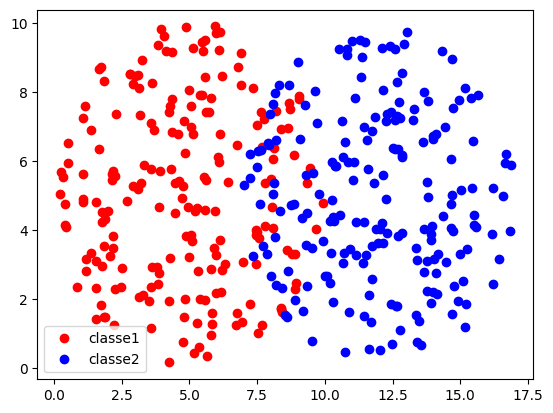

In [18]:
# Test du chargement des données
classe1, classe2 = load_data('train_set.mat')
plt.plot(classe1[:,0], classe1[:,1],'or', label='classe1')
plt.plot(classe2[:,0], classe2[:,1],'ob', label='classe2')
plt.legend(loc='best')
plt.show()

## 2.2 : Fonction d'entrainement

Implémentez une fonction `def entrainement(classe1, classe2):` dont le paramètre de sortie est :
- `x` : les poids du neurone.

Cette fonction utilisera les données `classe1` et `classe2`, et résoudra le problème d’optimisation présenté plus haut en utilisant la fonction fcrossentropy à définir ainsi que le backtracking pour déterminer le pas de descente. La méthode du gradient simple sera utilisée.

A l’intérieur de la fonction entrainement, on implémentera :

- `def fcrossentropy(x):` qui calcule f et g,
- `def backtrackingsimple(fct, x, d, alpha=1):` qui implémente la recherche de pas par backtracking,
- `def methgradient(fct, x0, maxiter=10**3):` qui applique la méthode du gradient.

On n’oublie pas d’ajouter une colonne de 1 (le biais) aux données.

In [19]:
def entrainement(classe1, classe2, methode='grad', pas='backtracking', maxiter=10**4, maxtime=10):
    n1, m = classe1.shape
    n2, m = classe2.shape

    # Ajout de la colonne de 1 pour le biais
    a1 = np.ones((n1, m+1))
    a2 = np.ones((n2, m+1))
    a1[:,1:] = classe1
    a2[:,1:] = classe2

    def fcrossentropy(x):
        # Classe 1
        exp1 = np.exp(-np.clip(a1 @ x, -50, 50))
        f1 = np.sum(np.log(1 + exp1))
        v1 = exp1 / (1 + exp1)
        g1 = -a1.T @ v1

        # Classe 2
        exp2 = np.exp(np.clip(a2 @ x, -50, 50))
        f2 = np.sum(np.log(1 + exp2))
        v2 = exp2 / (1 + exp2)
        g2 = a2.T @ v2

        f = f1 + f2
        g = g1 + g2
        return f, g

    def backtrackingsimple(fct, x, d, alpha=1):
        f0, g0 = fct(x)
        f1, g1 = fct(x + alpha * d)
        while f1 > f0:
            alpha /= 2
            f1, g1 = fct(x + alpha * d)
            if alpha < 1e-16:  # Condition d'arrêt sur le pas
                break
        return alpha

    def methgradient(fct, x0, maxiter=maxiter, maxtime=maxtime):
        start_time = time.time()
        temps = np.zeros(maxiter)
        fobj = np.zeros(maxiter)
        x = x0.copy()

        for k in range(maxiter):
            f, g = fct(x)
            d = -g
            if pas == "backtracking":
                alpha = backtrackingsimple(fct, x, d)

            x = x + alpha * d

            f, g = fct(x)
            fobj[k] = f
            temps[k] = time.time() - start_time
            if temps[k] > maxtime:
                return x, fobj[:k+1], temps[:k+1]

        return x, fobj, temps

    def methgradientACC(fct, x0, maxiter=maxiter, maxtime=maxtime):
        start_time = time.time()
        temps = np.zeros(maxiter)
        fobj = np.zeros(maxiter)
        x = x0.copy()
        y = x0.copy()

        for k in range(maxiter):
            xprec = x.copy()
            f, g = fct(y)
            d = -g
            if pas == "backtracking":
                alpha = backtrackingsimple(fct, y, d)

            x = y + alpha * d
            y = x + (k/(k+3))*(x - xprec)

            f, g = fct(x)
            fobj[k] = f
            temps[k] = time.time() - start_time
            if temps[k] > maxtime:
                return x, fobj[:k+1], temps[:k+1]

        return x, fobj, temps

    x0 = np.ones(m+1)
    if methode == 'grad':
        x, f, t = methgradient(fcrossentropy, x0)
    elif methode == 'gradacc':
        x, f, t = methgradientACC(fcrossentropy, x0)

    return x, f, t

## 2.3 : Validation du modèle


Implémentez une fonction `def validation(x, classe1_test, classe2_test)` qui, étant donné les poids `x` calculés par `entrainement`, calcule la prédiction du neurone sur les données test et retourne le taux de prédiction.

Rappel : 
$$ \hat{y} = \frac{1}{1 + e^{-x_0 - \sum_{j=1}^m a_j x_j}}. $$

Si $ \hat{y}\ge0.5 $, on prédit la classe 1, sinon la classe 2.

Cette fonction retournera le taux de prédiction, c'est-à-dire le pourcentage de données test correctement classées.

In [20]:
def validation(x, classe1_test, classe2_test):
    # Ajout de la colonne de 1
    n1, m = classe1_test.shape
    n2, m = classe2_test.shape
    a1 = np.ones((n1, m+1))
    a2 = np.ones((n2, m+1))
    a1[:, 1:] = classe1_test
    a2[:, 1:] = classe2_test

    # Prédictions
    y_pred_1 = 1/(1+np.exp(-(a1 @ x)))  # devrait être proche de 1
    y_pred_2 = 1/(1+np.exp(-(a2 @ x)))  # devrait être proche de 0

    # Pour classe1_test : vrai label = 1
    correct_1 = np.sum(y_pred_1 >= 0.5)
    # Pour classe2_test : vrai label = 0
    correct_2 = np.sum(y_pred_2 < 0.5)

    total_correct = correct_1 + correct_2
    total = n1 + n2
    return total_correct/total

## 2.4 : Expérimentations


A l’aide de ces fonctions, entraînez votre modèle sur `train_set.mat` puis validez-le sur `test_set.mat`. Calculez le taux de prédiction.

Créez également une figure qui montre l’évolution du taux de prédiction en fonction du pourcentage de données d’entraînement utilisées (en échantillonnant aléatoirement une fraction des données d’entraînement).

In [21]:
# Chargement des données d'entraînement
classe1petite, classe2petite = load_data('train_set.mat')

# Entraînement
poids, fp_gd_bt, tp_gd_bt = entrainement(classe1petite, classe2petite, methode='grad', pas='backtracking')
print("Poids entraînés :", poids)

# Chargement des données de test
classe1petiteTEST, classe2petiteTEST = load_data('test_set.mat')

def prediction_sigmoide(poids, donnee):
    # donnee est un vecteur de dimension m (sans biais)
    # poids[0] est le biais, poids[1:] sont les coefficients
    pred = 1/(1+np.exp(-(poids[0] + donnee @ poids[1:])))
    return np.round(pred)

correct = 0
nb1 = classe1petiteTEST.shape[0]
for i in range(nb1):
    ypredi = prediction_sigmoide(poids, classe1petiteTEST[i,:])
    if ypredi == 1:
        correct += 1

nb2 = classe2petiteTEST.shape[0]
for i in range(nb2):
    ypredi = prediction_sigmoide(poids, classe2petiteTEST[i,:])
    if ypredi == 0:
        correct += 1

print(f"Prédictions correctes: {correct} sur un total de {nb1+nb2} données.")

Poids entraînés : [11.77042321 -1.40980917 -0.01757658]
Prédictions correctes: 93 sur un total de 100 données.


## 2.5 : Evolution du taux de prédiction

Créez une figure qui montre l’évolution du taux de prédiction en fonction du pourcentage de données d’entraînement utilisées lors de l’entraînement. Utilisez `np.random.choice` ou similaire pour échantillonner aléatoirement les données d’entraînement.

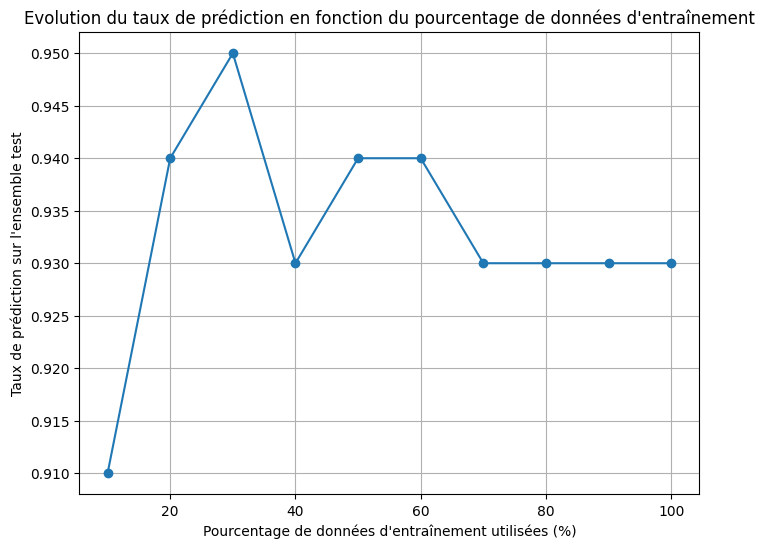

In [23]:
# Fusion des données d'entraînement et étiquetage
n1 = classe1petite.shape[0]
n2 = classe2petite.shape[0]
all_data = np.vstack((classe1petite, classe2petite))
all_labels = np.hstack((np.ones(n1), np.zeros(n2)))

pourcentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
taux = []
N = all_data.shape[0]

for p in pourcentages:
    nb_sample = int(N * p / 100)
    indices = np.random.choice(N, nb_sample, replace=False)
    data_sample = all_data[indices, :]
    labels_sample = all_labels[indices]

    # Reconstruire classe1_sample et classe2_sample
    idx_c1 = np.where(labels_sample == 1)[0]
    idx_c2 = np.where(labels_sample == 0)[0]
    classe1_sample = data_sample[idx_c1, :]
    classe2_sample = data_sample[idx_c2, :]

    # Entraîner sur l'échantillon
    poids_sample, _, _ = entrainement(classe1_sample, classe2_sample, methode='grad', pas='backtracking')

    # Tester sur l'ensemble test complet
    correct = 0
    nb1test = classe1petiteTEST.shape[0]
    for i in range(nb1test):
        ypred = prediction_sigmoide(poids_sample, classe1petiteTEST[i,:])
        if ypred == 1:
            correct += 1

    nb2test = classe2petiteTEST.shape[0]
    for i in range(nb2test):
        ypred = prediction_sigmoide(poids_sample, classe2petiteTEST[i,:])
        if ypred == 0:
            correct += 1

    taux_pred = correct / (nb1test + nb2test)
    taux.append(taux_pred)

# Affichage de l'évolution du taux de prédiction
plt.figure(figsize=(8,6))
plt.plot(pourcentages, taux, marker='o')
plt.xlabel("Pourcentage de données d'entraînement utilisées (%)")
plt.ylabel("Taux de prédiction sur l'ensemble test")
plt.title("Evolution du taux de prédiction en fonction du pourcentage de données d'entraînement")
plt.grid(True)
plt.show()

# Pour aller plus loin
## Accélération de la méthode et utilisation de données plus volumineuses


- Utiliser la méthode du gradient accéléré (déjà implémentée sous le nom `methGRADIENTACC` dans notre code précédent).
- Utiliser des données plus volumineuses, par exemple avec `n = 1398` et `m = 43586`, fournies dans `big_train_set.mat` et `big_test_set.mat`. 
- Les données fournies peuvent être sous forme sparse, il faudra donc adapter le code (par exemple en gardant les données en sparse, en utilisant `a.toarray()` si nécessaire, ou en vectorisant davantage les opérations).

**Remarque :** Le code ci-dessous se base sur le code précédemment donné. Il faudra s’assurer que la fonction `entrainement`, `prediction_sigmoide`, etc., acceptent des données dans le format fourni (sparse ou dense).

Ici, on montre un exemple d’adaptation pour charger les données sparse, et d’utilisation de la méthode du gradient accéléré sur le jeu de données large.

In [28]:
def load_data_sparse(name):
    mat_data = scipy.io.loadmat("dataNeurone/"+name)
    a = mat_data['a']  # données: n x m en format sparse
    y = mat_data['y']  # labels: 1 ou 0
    # Pour large dataset, 'a' peut être sparse
    if hasattr(a, 'toarray'):
        # On ne convertit pas forcément en dense, sauf si on veut le faire explicitement
        # Dans le cas où on veut le garder en sparse:
        # a = a.tocsc() 
        # Si besoin on le convertit, attention à la mémoire:
        a = a.tocsc()
    id1 = np.where(y == 1)[0]
    id2 = np.where(y == 0)[0]
    return a[id1, :], a[id2, :]

def entrainement(classe1, classe2, methode='grad', pas='backtracking', maxiter=10**4, maxtime=10):
    n1, m = classe1.shape
    n2, m = classe2.shape

    # Ici, les données peuvent être sparse. On peut soit:
    # - Garder les matrices sparse et adapter les opérations
    # - Convertir en dense si mémoire disponible
    # Exemple: si on reste en sparse, attention aux multiplications a@x
    # On ajoute la colonne de 1 pour le biais. Pour sparse:
    # On peut créer une sparse hstack.
    from scipy.sparse import hstack
    
    if isinstance(classe1, csc_matrix):
        a1 = hstack([np.ones((n1,1)), classe1], format='csc')
        a2 = hstack([np.ones((n2,1)), classe2], format='csc')
    else:
        a1 = np.ones((n1, m+1))
        a2 = np.ones((n2, m+1))
        a1[:,1:] = classe1
        a2[:,1:] = classe2

    def fcrossentropy(x):
        # x est un vecteur (m+1,)
        # Multiplications en sparse
        X1 = a1 @ x
        X2 = a2 @ x

        # On utilise np.clip pour éviter les overflow
        exp1 = np.exp(-np.clip(X1, -50, 50))
        f1 = np.sum(np.log(1+exp1))
        v1 = exp1/(1+exp1)
        # g1 = -a1.T @ v1
        # En sparse, a1.T * v1 reste valable
        g1 = -(a1.T @ v1)

        exp2 = np.exp(np.clip(X2, -50, 50))
        f2 = np.sum(np.log(1+exp2))
        v2 = exp2/(1+exp2)
        g2 = a2.T @ v2

        f = f1 + f2
        g = g1 + g2
        return f, g

    def backtracking(fct, x, d, alpha=1):
        f0, g0 = fct(x)
        f1, g1 = fct(x+alpha*d)
        while f1 > f0:
            alpha /= 2
            f1, g1 = fct(x+alpha*d)
            if alpha < 1e-16:
                break
        return alpha

    def methgradient(fct, x0, maxiter=maxiter, maxtime=maxtime):
        start_time = time.time()
        x = x0.copy()
        for k in range(maxiter):
            f, g = fct(x)
            d = -g
            alpha = backtracking(fct, x, d) if pas == "backtracking" else 1
            x = x + alpha*d
            if time.time()-start_time > maxtime:
                break
        return x

    def methgradientACC(fct, x0, maxiter=maxiter, maxtime=maxtime):
        start_time = time.time()
        x = x0.copy()
        y = x0.copy()
        for k in range(maxiter):
            xprec = x.copy()
            f, g = fct(y)
            d = -g
            alpha = backtracking(fct, y, d) if pas == "backtracking" else 1
            x = y + alpha*d
            y = x + (k/(k+3))*(x - xprec)
            if time.time()-start_time > maxtime:
                break
        return x

    x0 = np.ones(m+1)
    if methode == 'grad':
        x = methgradient(fcrossentropy, x0)
    elif methode == 'gradacc':
        x = methgradientACC(fcrossentropy, x0)

    return x

def prediction_sigmoide(poids, donnee):
    # donnee shape: (m,) et poids shape: (m+1,)
    # donnee peut être sparse, on fera:
    # pred = 1/(1+exp(-(poids[0] + sum_j donnee_j*poids[j+1])))
    # Si sparse:
    if hasattr(donnee, 'dot'):
        donnee_val = donnee.dot(poids[1:])
    else:
        donnee_val = donnee @ poids[1:]

    # Clipping de la valeur avant l'exponentielle
    z = np.clip(poids[0] + donnee_val, -50, 50)
    pred = 1/(1+np.exp(-z))
    return np.round(pred)

# Exemple d'utilisation avec le grand jeu de données
classe1_big_train, classe2_big_train = load_data_sparse('big_train_set.mat')
classe1_big_test, classe2_big_test = load_data_sparse('big_test_set.mat')

# Entrainement avec méthode du gradient accéléré sur le grand dataset
poids_big = entrainement(classe1_big_train, classe2_big_train, methode='gradacc', pas='backtracking', maxiter=1000, maxtime=180)

# Validation sur le grand jeu de données
correct = 0
nb1_test = classe1_big_test.shape[0]
nb2_test = classe2_big_test.shape[0]

# Vérification sur classe1 (labels réels = 1)
for i in range(nb1_test):
    # classe1_big_test[i,:] est un row sparse, prediction_sigmoide doit fonctionner
    ypred = prediction_sigmoide(poids_big, classe1_big_test[i,:])
    if ypred == 1:
        correct += 1

# Vérification sur classe2 (labels réels = 0)
for i in range(nb2_test):
    ypred = prediction_sigmoide(poids_big, classe2_big_test[i,:])
    if ypred == 0:
        correct += 1

taux_prediction_big = correct/(nb1_test+nb2_test)
print("Taux de prédiction sur le grand dataset:", round(taux_prediction_big, 4))

Taux de prédiction sur le grand dataset: 0.9548
